In [1]:
import pyspark
from pyspark.sql import SparkSession, functions as F
from pyspark.conf import SparkConf
from pyspark.context import SparkContext

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.types import (
    StructType, StructField,
    DoubleType, IntegerType, StringType, TimestampType
)

In [3]:
credentials_location = '/../path_to_google_credentials.json'

In [4]:
conf = SparkConf() \
    .setMaster("local[*]") \
    .setAppName('transform') \
    .set('spark.jars', 'https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar') \
    .set('spark.hadoop.google.cloud.auth.service.account.enable', 'true') \
    .set('spark.hadoop.google.cloud.auth.service.account.json.keyfile', credentials_location)

sc = SparkContext(conf=conf)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/01/27 19:00:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
hadoop_conf = sc._jsc.hadoopConfiguration()

hadoop_conf.set("fs.AbstractFileSystem.gs.impl",  "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFS")
hadoop_conf.set("fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
hadoop_conf.set("fs.gs.auth.service.account.json.keyfile", credentials_location)
hadoop_conf.set("fs.gs.auth.service.account.enable", "true")

In [6]:
spark = SparkSession.builder \
    .config(conf=sc.getConf()) \
    .getOrCreate()

In [7]:
spark.conf.set('spark.sql.repl.eagerEval.enabled', True)
spark.sparkContext.setLogLevel("ERROR")
spark.sparkContext.version

'3.3.2'

## Data Quality check

In [8]:
orders_schema = StructType([
    StructField('order_id', StringType(), True), 
    StructField('customer_id', StringType(), True), 
    StructField('order_status', StringType(), True), 
    StructField('order_purchase_timestamp', TimestampType(), True), 
    StructField('order_approved_at', TimestampType(), True),
    StructField('order_delivered_carrier_date', TimestampType(), True), 
    StructField('order_delivered_customer_date', TimestampType(), True),
    StructField('order_estimated_delivery_date', TimestampType(), True)
])
payments_schema = StructType([
    StructField('order_id', StringType(), True), 
    StructField('payment_sequential', IntegerType(), True), 
    StructField('payment_type', StringType(), True), 
    StructField('payment_installments', IntegerType(), True), 
    StructField('payment_value', DoubleType(), True)
])
items_schema = StructType([
    StructField('order_id', StringType(), True), 
    StructField('order_item_id', IntegerType(), True), 
    StructField('product_id', StringType(), True), 
    StructField('seller_id', StringType(), True), 
    StructField('shipping_limit_date', TimestampType(), True),
    StructField('price', DoubleType(), True), 
    StructField('freight_value', DoubleType(), True)
])
products_schema = StructType([
    StructField('product_id', StringType(), True), 
    StructField('product_category_name', StringType(), True), 
    StructField('product_name_lenght', StringType(), True), 
    StructField('product_description_lenght', IntegerType(), True), 
    StructField('product_photos_qty', IntegerType(), True),
    StructField('product_weight_g', DoubleType(), True), 
    StructField('product_length_cm', DoubleType(), True),
    StructField('product_height_cm', DoubleType(), True), 
    StructField('product_width_cm', DoubleType(), True)
])
category_schema = StructType([
    StructField('product_category_name', StringType(), True), 
    StructField('product_category_name_english', StringType(), True), 
])

In [9]:
BRAZIL_FILES = {
    "orders": {
        "file_name": "olist_orders_dataset", 
        "schema": orders_schema
    },
    "items": {
        "file_name": "olist_order_items_dataset", 
        "schema": items_schema
    },
    "order_payments": {
        "file_name": "olist_order_payments_dataset", 
        "schema": payments_schema
    },
    "products": {
        "file_name": "olist_products_dataset",
        "schema": products_schema
    },
    "category": {
        "file_name": "product_category_name_translation",
        "schema": category_schema
    }
}

In [10]:
brazil_dataframes = {}

for key, info in BRAZIL_FILES.items():
    df = spark.read.option("delimiter", ",") \
        .option("header", "true") \
        .csv(f'gs://airflow_spark_bucket_478915/raw/{info["file_name"]}.csv', schema=info["schema"])
    brazil_dataframes[key] = df
    print(f'--------------{key}----------------')
    row_number = brazil_dataframes[key].count()
    number_of_columns = len(brazil_dataframes[key].columns)
    print(f'Row number: {row_number}, number of columns: {number_of_columns}')
    brazil_dataframes[key].show(truncate=False)
    df.printSchema()
    brazil_dataframes[key].describe().show()

--------------orders----------------


Row number: 99441, number of columns: 8


+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

+-------+--------------------+--------------------+------------+
|summary|            order_id|         customer_id|order_status|
+-------+--------------------+--------------------+------------+
|  count|               99441|               99441|       99441|
|   mean|                null|                null|        null|
| stddev|                null|                null|        null|
|    min|00010242fe8c5a6d1...|00012a2ce6f8dcda2...|    approved|
|    max|fffe41c64501cc87c...|ffffe8b65bbe3087b...| unavailable|
+-------+--------------------+--------------------+------------+

--------------items----------------


Row number: 112650, number of columns: 7


...

+-------+--------------------+------------------+------------+--------------------+------------------+
|summary|            order_id|payment_sequential|payment_type|payment_installments|     payment_value|
+-------+--------------------+------------------+------------+--------------------+------------------+
|  count|              103886|            103886|      103886|              103886|            103886|
|   mean|                null|1.0926785129853878|        null|   2.853348863176944|154.10038041698792|
| stddev|                null|0.7065837791949958|        null|   2.687050673856492|  217.494063864724|
|    min|00010242fe8c5a6d1...|                 1|      boleto|                   0|               0.0|
|    max|fffe41c64501cc87c...|                29|     voucher|                  24|          13664.08|
+-------+--------------------+------------------+------------+--------------------+------------------+

--------------products----------------


Row number: 32951, number of columns: 9


+--------------------------------+--------------------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name           |product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+--------------------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff4541ed26657ea517e5|perfumaria                      |40                 |287                       |1                 |225.0           |16.0             |10.0             |14.0            |
|3aa071139cb16b67ca9e5dea641aaa2f|artes                           |44                 |276                       |1                 |1000.0          |30.0             |18.0            

+-------+--------------------+---------------------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|summary|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|  product_weight_g| product_length_cm| product_height_cm|  product_width_cm|
+-------+--------------------+---------------------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|  count|               32951|                32341|              32341|                     32341|             32341|             32949|             32949|             32949|             32949|
|   mean|                null|                 null|  48.47694876472589|         771.4952846232337|2.1889861166939797|2276.4724877841513| 30.81507784758263|16.937661234028347|23.196728277034204|
| stddev|                

+---------------------------+-----------------------------+
|product_category_name      |product_category_name_english|
+---------------------------+-----------------------------+
|beleza_saude               |health_beauty                |
|informatica_acessorios     |computers_accessories        |
|automotivo                 |auto                         |
|cama_mesa_banho            |bed_bath_table               |
|moveis_decoracao           |furniture_decor              |
|esporte_lazer              |sports_leisure               |
|perfumaria                 |perfumery                    |
|utilidades_domesticas      |housewares                   |
|telefonia                  |telephony                    |
|relogios_presentes         |watches_gifts                |
|alimentos_bebidas          |food_drink                   |
|bebes                      |baby                         |
|papelaria                  |stationery                   |
|tablets_impressao_imagem   |tablets_pri

In [11]:
brazil_dataframes.keys()

dict_keys(['orders', 'items', 'order_payments', 'products', 'category'])

In [12]:
summary = {}

for key, df in brazil_dataframes.items():
    summary = {}
    for column in brazil_dataframes[key].columns:
        count_nulls = brazil_dataframes[key].filter(F.col(column).isNull()).count()
        summary[column] = count_nulls
    print(key)
    print(pd.Series(summary).to_frame(name='nulls_count'))

orders
                               nulls_count
order_id                                 0
customer_id                              0
order_status                             0
order_purchase_timestamp                 0
order_approved_at                      160
order_delivered_carrier_date          1783
order_delivered_customer_date         2965
order_estimated_delivery_date            0


items
                     nulls_count
order_id                       0
order_item_id                  0
product_id                     0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0


order_payments
                      nulls_count
order_id                        0
payment_sequential              0
payment_type                    0
payment_installments            0
payment_value                   0


products
                            nulls_count
product_id                            0
product_category_name               610
product_name_lenght                 610
product_description_lenght          610
product_photos_qty                  610
product_weight_g                      2
product_length_cm                     2
product_height_cm                     2
product_width_cm                      2


category
                               nulls_count
product_category_name                    0
product_category_name_english            0


## Create cumulative table

In [13]:
items = (
    brazil_dataframes['items']
        .withColumn(
            "total_price",
            F.col("price") + F.col("freight_value"))
)

In [14]:
orders = (
    brazil_dataframes['orders']
        .withColumn(
            "order_purchase_date",
            F.to_date(F.col("order_purchase_timestamp"))
        )
        .withColumn(
            "delivery_time_in_days",
            F.when(
                F.col("order_delivered_customer_date").isNotNull(),
                F.datediff(
                    F.to_date(F.col("order_delivered_customer_date")),
                    F.to_date(F.col("order_purchase_timestamp"))
                )
            ).otherwise(None)
        )
        .withColumn(
            "week_end_date",
            F.date_add(F.col("order_purchase_timestamp"), 6 - F.dayofweek("order_purchase_timestamp"))
        )
        .withColumn(
            "month_end_date",
            F.last_day("order_purchase_timestamp")
        )
        .filter(F.col("order_status") == "delivered")
    .select(
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_purchase_date",
        "delivery_time_in_days",
        "week_end_date",
        "month_end_date"
    )
)

orders.show()

+--------------------+--------------------+------------+------------------------+-----------------------------+-------------------+---------------------+-------------+--------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|order_delivered_customer_date|order_purchase_date|delivery_time_in_days|week_end_date|month_end_date|
+--------------------+--------------------+------------+------------------------+-----------------------------+-------------------+---------------------+-------------+--------------+
|e481f51cbdc54678b...|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|          2017-10-10 21:25:13|         2017-10-02|                    8|   2017-10-06|    2017-10-31|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|   delivered|     2018-07-24 20:41:37|          2018-08-07 15:27:45|         2018-07-24|                   14|   2018-07-27|    2018-07-31|
|47770eb9100c2d0c4...|41ce2a54c0b03bf34...|   delivered|     2018-08-08 08:38:49|    

In [15]:
payments = brazil_dataframes['order_payments']
products = brazil_dataframes['products']
category = brazil_dataframes['category']

In [16]:
products = products.join(category.hint("broadcast"), "product_category_name")
products = products.select(
    "product_id",
    "product_category_name",
    "product_category_name_english")
products.toPandas()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
...,...,...,...
32323,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor
32324,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights
32325,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table
32326,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories


In [17]:
orders_with_items = orders.join(items, "order_id").join(products, "product_id").join(payments, "order_id")
orders_with_items.toPandas()

,order_id,product_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_purchase_date,delivery_time_in_days,week_end_date,month_end_date,...,shipping_limit_date,price,freight_value,total_price,product_category_name,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,0132451f29a10b66a5cf1bacc85f9afe,42a2bd596fda1baef5719cb74f73030c,1c5b37d20011c637ad1a5b6d423c7483,delivered,2017-11-08 17:08:56,2017-11-17 18:58:42,2017-11-08,9.0,2017-11-10,2017-11-30,...,2017-11-21 17:08:27,89.90,17.88,107.78,cama_mesa_banho,bed_bath_table,1,credit_card,3,215.56
1,01e662008f03009eb9b97f9333fcd6b4,460a66fcc404a3d7306d5f50fcb2d18a,bd13ebe5d7f8f2923430da33ffcf40ec,delivered,2018-06-30 10:04:41,2018-07-14 13:56:47,2018-06-30,14.0,2018-06-29,2018-06-30,...,2018-07-03 10:15:12,24.98,12.84,37.82,utilidades_domesticas,housewares,1,credit_card,3,37.82
2,036091098bdc85e780fc3594006276b7,13b4ff901d43edec666e3253b14b3a8f,92dd835c0a01f474014b0a888b5bef93,delivered,2018-07-19 12:59:52,2018-07-27 18:28:23,2018-07-19,8.0,2018-07-20,2018-07-31,...,2018-07-24 14:50:20,630.00,64.49,694.49,cama_mesa_banho,bed_bath_table,1,boleto,1,1388.98
3,036091098bdc85e780fc3594006276b7,13b4ff901d43edec666e3253b14b3a8f,92dd835c0a01f474014b0a888b5bef93,delivered,2018-07-19 12:59:52,2018-07-27 18:28:23,2018-07-19,8.0,2018-07-20,2018-07-31,...,2018-07-24 14:50:20,630.00,64.49,694.49,cama_mesa_banho,bed_bath_table,1,boleto,1,1388.98
4,0452092bf08cf43ddab32ebec9e75d2d,290ada89b05e1dca2a4fe42f1cfc012e,bc2723356fa3f373b455c0a3112dc495,delivered,2017-02-21 10:53:34,2017-03-16 10:41:44,2017-02-21,23.0,2017-02-24,2017-02-28,...,2017-02-25 10:53:34,29.90,20.40,50.30,telefonia_fixa,fixed_telephony,1,boleto,1,50.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113379,f2f949c0ccde761a4485b5535eae0467,e68e6b9f909d74c3b23c3b249c830657,7955dc8ce73a68fe390f4e5c54e855ba,delivered,2017-11-13 21:54:11,2017-11-24 20:32:03,2017-11-13,11.0,2017-11-17,2017-11-30,...,2017-11-20 22:10:41,341.40,17.14,358.54,relogios_presentes,watches_gifts,1,credit_card,2,358.54
113380,f37cdd40de53fd4b961aa07433c716fc,27f53b8bf57426361b3e0174c16232e3,474b9f393f2d19999e4a9fc7ce3a898e,delivered,2018-03-02 12:58:20,2018-04-05 19:09:30,2018-03-02,34.0,2018-03-02,2018-03-31,...,2018-03-08 13:15:39,119.90,15.59,135.49,esporte_lazer,sports_leisure,1,credit_card,1,135.49
113381,f7ca7b451be2d25f6b0918320026570a,91846781ef75057e134949400768e272,c4f65865007c8df12b5b1fe0d4da652b,delivered,2018-06-03 16:35:41,2018-06-08 18:20:15,2018-06-03,5.0,2018-06-08,2018-06-30,...,2018-06-11 16:50:36,134.99,27.67,162.66,esporte_lazer,sports_leisure,1,credit_card,2,162.66
113382,fb436a0beef49b493351afe287150239,e7d5464b94c9a5963f7c686fc80145ad,fab1deb9a9ec207df528ba82a18d848a,delivered,2018-06-28 12:19:32,2018-07-06 14:38:53,2018-06-28,8.0,2018-06-29,2018-06-30,...,2018-07-05 12:31:13,139.00,22.90,161.90,relogios_presentes,watches_gifts,1,credit_card,4,161.90


In [18]:
orders_with_items.columns

['order_id',
 'product_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_delivered_customer_date',
 'order_purchase_date',
 'delivery_time_in_days',
 'week_end_date',
 'month_end_date',
 'order_item_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'total_price',
 'product_category_name',
 'product_category_name_english',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [19]:
orders_with_items = orders_with_items.select(
    'order_id',
    'product_id',
    'customer_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_purchase_date',
    'delivery_time_in_days',
    'week_end_date',
    'month_end_date',
    'order_item_id',
    'seller_id',
    'price',
    'freight_value',
    'total_price',
    F.col("product_category_name_english").alias("product_category_name"),
    'payment_sequential',
    'payment_type',
    'payment_value'
)

In [20]:
orders_with_items.toPandas()

,order_id,product_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_purchase_date,delivery_time_in_days,week_end_date,month_end_date,order_item_id,seller_id,price,freight_value,total_price,product_category_name,payment_sequential,payment_type,payment_value
0,0132451f29a10b66a5cf1bacc85f9afe,42a2bd596fda1baef5719cb74f73030c,1c5b37d20011c637ad1a5b6d423c7483,delivered,2017-11-08 17:08:56,2017-11-17 18:58:42,2017-11-08,9.0,2017-11-10,2017-11-30,1,da8622b14eb17ae2831f4ac5b9dab84a,89.90,17.88,107.78,bed_bath_table,1,credit_card,215.56
1,01e662008f03009eb9b97f9333fcd6b4,460a66fcc404a3d7306d5f50fcb2d18a,bd13ebe5d7f8f2923430da33ffcf40ec,delivered,2018-06-30 10:04:41,2018-07-14 13:56:47,2018-06-30,14.0,2018-06-29,2018-06-30,1,ffc470761de7d0232558ba5e786e57b7,24.98,12.84,37.82,housewares,1,credit_card,37.82
2,036091098bdc85e780fc3594006276b7,13b4ff901d43edec666e3253b14b3a8f,92dd835c0a01f474014b0a888b5bef93,delivered,2018-07-19 12:59:52,2018-07-27 18:28:23,2018-07-19,8.0,2018-07-20,2018-07-31,1,1835b56ce799e6a4dc4eddc053f04066,630.00,64.49,694.49,bed_bath_table,1,boleto,1388.98
3,036091098bdc85e780fc3594006276b7,13b4ff901d43edec666e3253b14b3a8f,92dd835c0a01f474014b0a888b5bef93,delivered,2018-07-19 12:59:52,2018-07-27 18:28:23,2018-07-19,8.0,2018-07-20,2018-07-31,2,1835b56ce799e6a4dc4eddc053f04066,630.00,64.49,694.49,bed_bath_table,1,boleto,1388.98
4,0452092bf08cf43ddab32ebec9e75d2d,290ada89b05e1dca2a4fe42f1cfc012e,bc2723356fa3f373b455c0a3112dc495,delivered,2017-02-21 10:53:34,2017-03-16 10:41:44,2017-02-21,23.0,2017-02-24,2017-02-28,1,54aa8463e87776b5612f4bdc4bd5d4de,29.90,20.40,50.30,fixed_telephony,1,boleto,50.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113379,f2f949c0ccde761a4485b5535eae0467,e68e6b9f909d74c3b23c3b249c830657,7955dc8ce73a68fe390f4e5c54e855ba,delivered,2017-11-13 21:54:11,2017-11-24 20:32:03,2017-11-13,11.0,2017-11-17,2017-11-30,1,f4c4daa86e30c7e5a553a8d518ac03a5,341.40,17.14,358.54,watches_gifts,1,credit_card,358.54
113380,f37cdd40de53fd4b961aa07433c716fc,27f53b8bf57426361b3e0174c16232e3,474b9f393f2d19999e4a9fc7ce3a898e,delivered,2018-03-02 12:58:20,2018-04-05 19:09:30,2018-03-02,34.0,2018-03-02,2018-03-31,1,4d6d651bd7684af3fffabd5f08d12e5a,119.90,15.59,135.49,sports_leisure,1,credit_card,135.49
113381,f7ca7b451be2d25f6b0918320026570a,91846781ef75057e134949400768e272,c4f65865007c8df12b5b1fe0d4da652b,delivered,2018-06-03 16:35:41,2018-06-08 18:20:15,2018-06-03,5.0,2018-06-08,2018-06-30,1,530ec6109d11eaaf87999465c6afee01,134.99,27.67,162.66,sports_leisure,1,credit_card,162.66
113382,fb436a0beef49b493351afe287150239,e7d5464b94c9a5963f7c686fc80145ad,fab1deb9a9ec207df528ba82a18d848a,delivered,2018-06-28 12:19:32,2018-07-06 14:38:53,2018-06-28,8.0,2018-06-29,2018-06-30,1,58f1a6197ed863543e0136bdedb3fce2,139.00,22.90,161.90,watches_gifts,1,credit_card,161.90


In [21]:
column_list = ['order_status', 'payment_type', 'product_category_name']

In [22]:
for column in column_list:
    orders_with_items.select([column]).distinct().show(truncate=False)

+------------+
|order_status|
+------------+
|delivered   |
+------------+



+------------+
|payment_type|
+------------+
|boleto      |
|credit_card |
|voucher     |
|debit_card  |
+------------+



+---------------------------------------+
|product_category_name                  |
+---------------------------------------+
|art                                    |
|flowers                                |
|home_construction                      |
|fashion_male_clothing                  |
|kitchen_dining_laundry_garden_furniture|
|small_appliances                       |
|la_cuisine                             |
|bed_bath_table                         |
|signaling_and_security                 |
|office_furniture                       |
|computers                              |
|watches_gifts                          |
|auto                                   |
|fashion_bags_accessories               |
|construction_tools_lights              |
|cool_stuff                             |
|cds_dvds_musicals                      |
|food                                   |
|computers_accessories                  |
|perfumery                              |
+---------------------------------

In [23]:
orders_with_items = orders_with_items.dropDuplicates()

In [24]:
orders_with_items.createOrReplaceTempView("orders_with_items")

## Prepare table for analysis

In [25]:
spark.sql(
    """
    SELECT 
        week_end_date AS observation_week,
        product_category_name AS category,
        payment_type,
        seller_id,
        customer_id,
        order_id,
        delivery_time_in_days,
        order_item_id,
        price,
        freight_value,
        total_price
    FROM orders_with_items
    """
).createOrReplaceTempView("grouped_results")

In [26]:
spark.table("grouped_results").count()

113384

In [27]:
spark.table("grouped_results").count()

113384

## Backbone

In [28]:
spark.sql(
    """
    WITH per_pair AS (
        SELECT
            category,
            MIN(observation_week) AS start_week,
            MAX(observation_week) AS end_week
        FROM grouped_results
        GROUP BY category
        ORDER BY start_week ASC
    )
    SELECT
        category,
        EXPLODE(
            SEQUENCE(start_week, end_week, INTERVAL 1 WEEK)
        ) AS observation_week
    FROM per_pair
    """).createOrReplaceTempView("backbone")

In [29]:
spark.table("backbone").count()

5995

In [30]:
spark.sql(
    """
    SELECT
        MIN(observation_week) AS start_week,
        MAX(observation_week) AS end_week
    FROM grouped_results
    --WHERE category = 'fashion_bags_accessories'
    WHERE category = 'cds_dvds_musicals'
    GROUP BY category
    """
).toPandas()

,start_week,end_week
0,2017-07-07,2018-04-20


In [31]:
spark.sql(
    """
    SELECT DISTINCT
        LAST_DAY(observation_week) AS observation_month
    FROM grouped_results
    WHERE category = 'fashion_bags_accessories'
    order by 1
    """
).toPandas()

,observation_month
0,2016-10-31
1,2016-12-31
2,2017-01-31
3,2017-02-28
4,2017-03-31
5,2017-04-30
6,2017-05-31
7,2017-06-30
8,2017-07-31
9,2017-08-31


In [32]:
spark.sql(
    """
    SELECT DISTINCT
        b.observation_week,
        LAST_DAY(b.observation_week) AS observation_month,
        b.category,
        IF(gr.observation_week IS NULL, True, False) AS is_interpolated,
        gr.seller_id,
        gr.customer_id,
        gr.delivery_time_in_days,
        gr.order_id,
        gr.order_item_id,
        gr.freight_value,
        gr.total_price
    FROM backbone AS b
    LEFT JOIN grouped_results AS gr
        ON b.observation_week = gr.observation_week
        AND b.category = gr.category
    """
).createOrReplaceTempView("join_backbone")

In [33]:
spark.sql("select * from join_backbone where category = 'cds_dvds_musicals' order by 1 LIMIT 20").toPandas()

,observation_week,observation_month,category,is_interpolated,seller_id,customer_id,delivery_time_in_days,order_id,order_item_id,freight_value,total_price
0,2017-07-07,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,328d7a69cb9cbaf088eed3ed778804bb,12.0,37104fd8b73d0691fda9491fe8906808,2.0,16.11,61.11
1,2017-07-07,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,328d7a69cb9cbaf088eed3ed778804bb,12.0,37104fd8b73d0691fda9491fe8906808,1.0,16.11,61.11
2,2017-07-14,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,9cedc9b5217be6c8cb89e73ce5390c1e,8.0,9c782cb7854e5dfa91927cfca8949eb8,1.0,16.11,61.11
3,2017-07-14,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,abc3efee9e5e539286ff709b2f654d8f,12.0,6eac247f4bce09d7fe35d7cf903c74b3,1.0,16.11,61.11
4,2017-07-21,2017-07-31,cds_dvds_musicals,True,None,None,NaN,None,NaN,NaN,NaN
5,2017-07-28,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,b3137029b6e1d3d2e172a8725c0d3e5b,15.0,742a36775534b588ed2a62ba4c2d9cd7,1.0,9.94,54.94
6,2017-08-04,2017-08-31,cds_dvds_musicals,True,None,None,NaN,None,NaN,NaN,NaN
7,2017-08-11,2017-08-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,f81bb64a1e672e6cbd0e027046db8533,7.0,615ca9b2afeaf5644ae8cef64797132e,2.0,16.11,61.11
8,2017-08-11,2017-08-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,f81bb64a1e672e6cbd0e027046db8533,7.0,615ca9b2afeaf5644ae8cef64797132e,1.0,16.11,61.11
9,2017-08-18,2017-08-31,cds_dvds_musicals,True,None,None,NaN,None,NaN,NaN,NaN


In [34]:
spark.sql(
    """
    SELECT 
        exploded_data.frequency AS frequency,
        exploded_data.period_end_date AS period_end_date,
        jb.category,
        jb.is_interpolated,
        jb.seller_id,
        COALESCE(jb.customer_id, NULL) AS customer_id,
        COALESCE(jb.delivery_time_in_days, 0) AS delivery_time_in_days,
        COALESCE(jb.order_id, NULL) AS order_id,
        COALESCE(jb.order_item_id, 0) AS order_item_id,
        COALESCE(jb.freight_value, 0) AS freight_value,
        COALESCE(jb.total_price, 0) AS total_price
    FROM join_backbone jb
    LATERAL VIEW EXPLODE(
        ARRAY(
            NAMED_STRUCT("frequency", 'MONTHLY', "period_end_date", observation_month),
            NAMED_STRUCT("frequency", 'WEEKLY', "period_end_date", observation_week)
        )
    ) AS exploded_data
    """
).createOrReplaceTempView("exploded_results")

In [35]:
spark.sql("select *, COALESCE(total_price, 0) from exploded_results where category = 'cds_dvds_musicals' order by 2 LIMIT 20").toPandas()

,frequency,period_end_date,category,is_interpolated,seller_id,customer_id,delivery_time_in_days,order_id,order_item_id,freight_value,total_price,"coalesce(total_price, 0)"
0,WEEKLY,2017-07-07,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,328d7a69cb9cbaf088eed3ed778804bb,12,37104fd8b73d0691fda9491fe8906808,2,16.11,61.11,61.11
1,WEEKLY,2017-07-07,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,328d7a69cb9cbaf088eed3ed778804bb,12,37104fd8b73d0691fda9491fe8906808,1,16.11,61.11,61.11
2,WEEKLY,2017-07-14,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,9cedc9b5217be6c8cb89e73ce5390c1e,8,9c782cb7854e5dfa91927cfca8949eb8,1,16.11,61.11,61.11
3,WEEKLY,2017-07-14,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,abc3efee9e5e539286ff709b2f654d8f,12,6eac247f4bce09d7fe35d7cf903c74b3,1,16.11,61.11,61.11
4,WEEKLY,2017-07-21,cds_dvds_musicals,True,None,None,0,None,0,0.00,0.00,0.00
5,WEEKLY,2017-07-28,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,b3137029b6e1d3d2e172a8725c0d3e5b,15,742a36775534b588ed2a62ba4c2d9cd7,1,9.94,54.94,54.94
6,MONTHLY,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,b3137029b6e1d3d2e172a8725c0d3e5b,15,742a36775534b588ed2a62ba4c2d9cd7,1,9.94,54.94,54.94
7,MONTHLY,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,328d7a69cb9cbaf088eed3ed778804bb,12,37104fd8b73d0691fda9491fe8906808,1,16.11,61.11,61.11
8,MONTHLY,2017-07-31,cds_dvds_musicals,False,4e922959ae960d389249c378d1c939f5,abc3efee9e5e539286ff709b2f654d8f,12,6eac247f4bce09d7fe35d7cf903c74b3,1,16.11,61.11,61.11
9,MONTHLY,2017-07-31,cds_dvds_musicals,True,None,None,0,None,0,0.00,0.00,0.00


In [36]:
spark.sql(
    """
    SELECT 
        period_end_date,
        frequency,
        category,
        seller,
        MAX(number_of_customers) AS number_of_customers,
        MAX(average_delivery_time_in_days) AS average_delivery_time_in_days,
        MAX(number_of_orders) AS number_of_orders,
        SUM(item_inventory) AS item_inventory,
        SUM(total_transport_price) AS total_transport_price,
        SUM(total_value) AS total_value
    FROM (
        SELECT DISTINCT
            period_end_date,
            frequency,
            COALESCE(category, 'All') AS category,
            COALESCE(seller_id, 'All') AS seller,
            COUNT(customer_id) AS number_of_customers,
            ROUND(AVG(delivery_time_in_days), 2) AS average_delivery_time_in_days,
            COUNT(order_id) AS number_of_orders,
            SUM(order_item_id) AS item_inventory,
            ROUND(SUM(freight_value), 2) AS total_transport_price,
            ROUND(SUM(total_price), 2) AS total_value
        FROM exploded_results
        GROUP BY GROUPING SETS (
            (period_end_date, frequency),
            (period_end_date, frequency, category),
            (period_end_date, frequency, category, seller_id)
        ) 
    ) a
    GROUP BY period_end_date, frequency, category, seller
    """
).createOrReplaceTempView("final_results")

In [37]:
spark.table("final_results").count()

75121

In [38]:
spark.sql("select * from final_results where category = 'cds_dvds_musicals'  and frequency = 'WEEKLY'  and seller = 'All' order by 1 LIMIT 20").toPandas()

,period_end_date,frequency,category,seller,number_of_customers,average_delivery_time_in_days,number_of_orders,item_inventory,total_transport_price,total_value
0,2017-07-07,WEEKLY,cds_dvds_musicals,All,2,12.0,2,3,32.22,122.22
1,2017-07-14,WEEKLY,cds_dvds_musicals,All,2,10.0,2,2,32.22,122.22
2,2017-07-21,WEEKLY,cds_dvds_musicals,All,0,0.0,0,0,0.00,0.00
3,2017-07-28,WEEKLY,cds_dvds_musicals,All,1,15.0,1,1,9.94,54.94
4,2017-08-04,WEEKLY,cds_dvds_musicals,All,0,0.0,0,0,0.00,0.00
5,2017-08-11,WEEKLY,cds_dvds_musicals,All,2,7.0,2,3,32.22,122.22
6,2017-08-18,WEEKLY,cds_dvds_musicals,All,0,0.0,0,0,0.00,0.00
7,2017-08-25,WEEKLY,cds_dvds_musicals,All,1,7.0,1,1,9.94,54.94
8,2017-09-01,WEEKLY,cds_dvds_musicals,All,0,0.0,0,0,0.00,0.00
9,2017-09-08,WEEKLY,cds_dvds_musicals,All,0,0.0,0,0,0.00,0.00


In [49]:
results = spark.sql(
    """
    select 
        period_end_date, 
        category, 
        total_value 
    FROM final_results 
    WHERE frequency = 'MONTHLY'  
    AND seller = 'All' 
    AND category != 'All'
    """).toPandas()

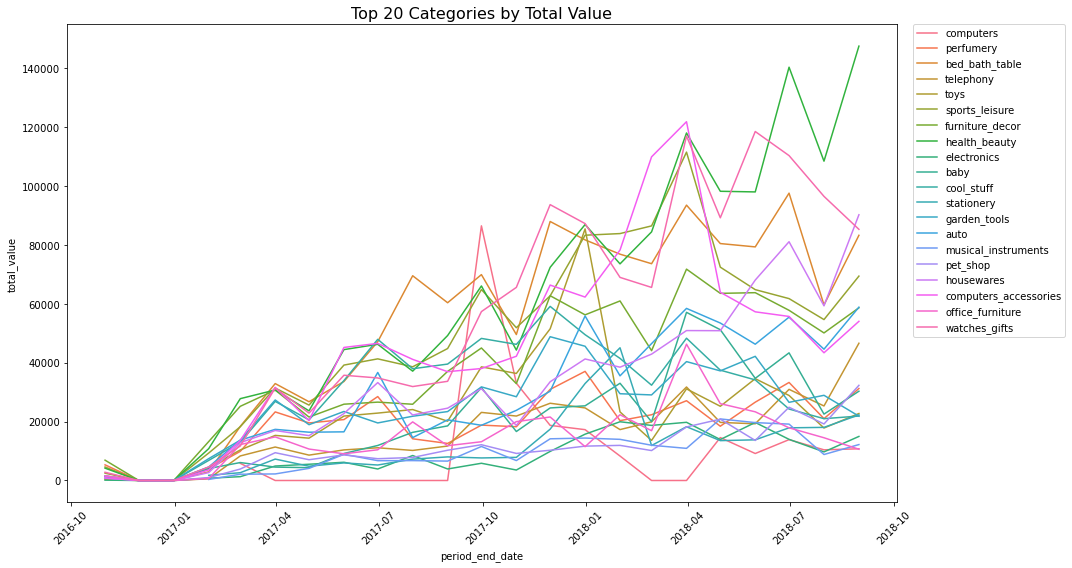

In [50]:
top_20_categories = results.groupby("category")["total_value"].sum().nlargest(20).index
results_top_20 = results[results["category"].isin(top_20_categories)]

plt.figure(figsize=(15, 8))

plot = sns.lineplot(
    data=results_top_20, 
    x="period_end_date", 
    y="total_value", 
    hue="category",
    linewidth=1.5
)

plt.title("Top 20 Categories by Total Value", fontsize=16)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()

## Forwardfill

In [51]:
spark.sql(
    """
    SELECT 
        period_end_date,
        frequency,
        category,
        seller,
        total_value,
        LAST_VALUE(NULLIF(total_value, 0), TRUE) OVER (
            PARTITION BY category, seller 
            ORDER BY period_end_date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS total_value_filled
        FROM final_results
        where category = 'cds_dvds_musicals'
        AND frequency = 'MONTHLY'
        AND seller = 'All'
        order by 1
    """
).toPandas()

,period_end_date,frequency,category,seller,total_value,total_value_filled
0,2017-07-31,MONTHLY,cds_dvds_musicals,All,299.38,299.38
1,2017-08-31,MONTHLY,cds_dvds_musicals,All,177.16,177.16
2,2017-09-30,MONTHLY,cds_dvds_musicals,All,0.00,177.16
3,2017-10-31,MONTHLY,cds_dvds_musicals,All,61.11,61.11
4,2017-11-30,MONTHLY,cds_dvds_musicals,All,224.82,224.82
5,2017-12-31,MONTHLY,cds_dvds_musicals,All,74.94,74.94
6,2018-01-31,MONTHLY,cds_dvds_musicals,All,0.00,74.94
7,2018-02-28,MONTHLY,cds_dvds_musicals,All,0.00,74.94
8,2018-03-31,MONTHLY,cds_dvds_musicals,All,0.00,74.94
9,2018-04-30,MONTHLY,cds_dvds_musicals,All,117.58,117.58


## Rolled metrics

In [52]:
spark.sql(
    """
    SELECT
        period_end_date,
        frequency,
        category,
        seller,
        total_value,
        ROUND(AVG(total_value) OVER four_week_window, 2) AS total_value_rolled
    FROM final_results
    WHERE category = 'cds_dvds_musicals'
        AND frequency = 'WEEKLY'
        AND seller = 'All'
        ORDER BY 1
    WINDOW four_week_window AS (
        PARTITION BY category
        ORDER BY CAST(period_end_date AS TIMESTAMP)
        RANGE BETWEEN INTERVAL 22 DAYS PRECEDING AND CURRENT ROW
    )
    """
).toPandas()

,period_end_date,frequency,category,seller,total_value,total_value_rolled
0,2017-07-07,WEEKLY,cds_dvds_musicals,All,122.22,122.22
1,2017-07-14,WEEKLY,cds_dvds_musicals,All,122.22,122.22
2,2017-07-21,WEEKLY,cds_dvds_musicals,All,0.00,81.48
3,2017-07-28,WEEKLY,cds_dvds_musicals,All,54.94,74.85
4,2017-08-04,WEEKLY,cds_dvds_musicals,All,0.00,44.29
5,2017-08-11,WEEKLY,cds_dvds_musicals,All,122.22,44.29
6,2017-08-18,WEEKLY,cds_dvds_musicals,All,0.00,44.29
7,2017-08-25,WEEKLY,cds_dvds_musicals,All,54.94,44.29
8,2017-09-01,WEEKLY,cds_dvds_musicals,All,0.00,44.29
9,2017-09-08,WEEKLY,cds_dvds_musicals,All,0.00,13.74
